In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("hotel_bookings_clean.csv")

In [3]:
print(df.shape)

df.head()

(87377, 37)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests,total_nights,family,arrival_month_num,season
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0.0,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,2.0,0,0,7,Summer
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0.0,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,2.0,0,0,7,Summer
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,1.0,1,0,7,Summer
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,1.0,1,0,7,Summer
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,2.0,2,0,7,Summer


In [4]:
cancel_rate = (
    df['is_canceled']
    .value_counts(normalize=True)
    *100
)

print(cancel_rate)

is_canceled
0    72.50535
1    27.49465
Name: proportion, dtype: float64


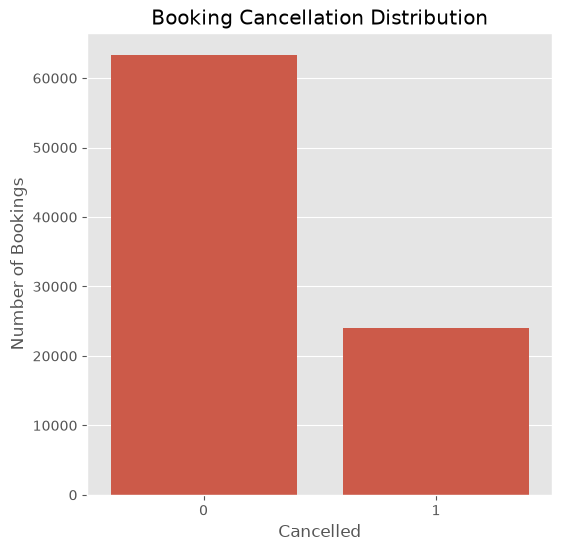

In [5]:
plt.figure(figsize=(6,6))

sns.countplot(
    data=df,
    x='is_canceled'
)

plt.title("Booking Cancellation Distribution")
plt.xlabel("Cancelled")
plt.ylabel("Number of Bookings")

plt.show()

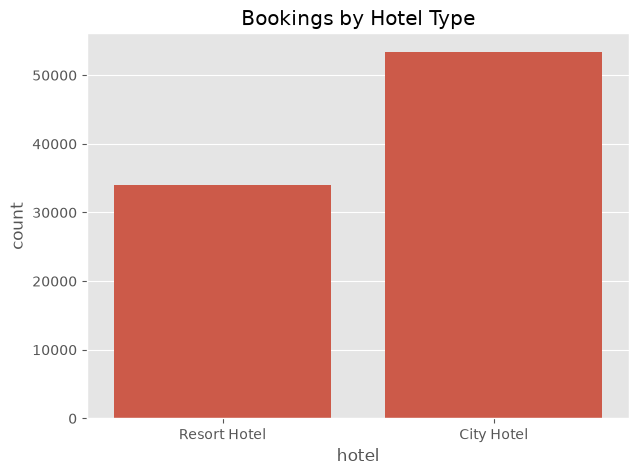

In [6]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='hotel'
)

plt.title("Bookings by Hotel Type")

plt.show()

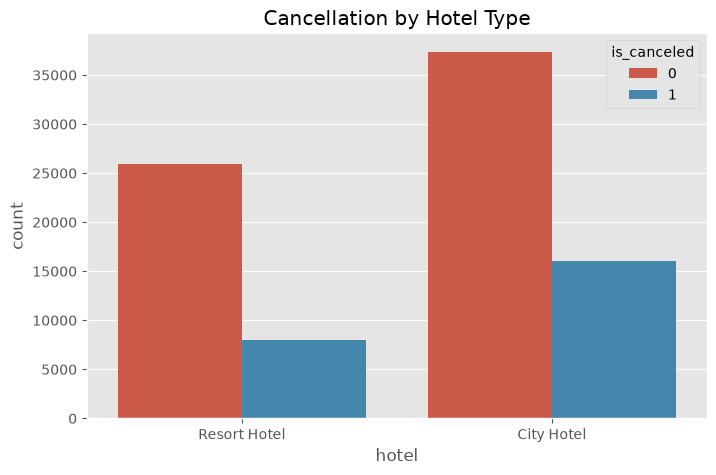

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='hotel',
    hue='is_canceled'
)

plt.title("Cancellation by Hotel Type")

plt.show()

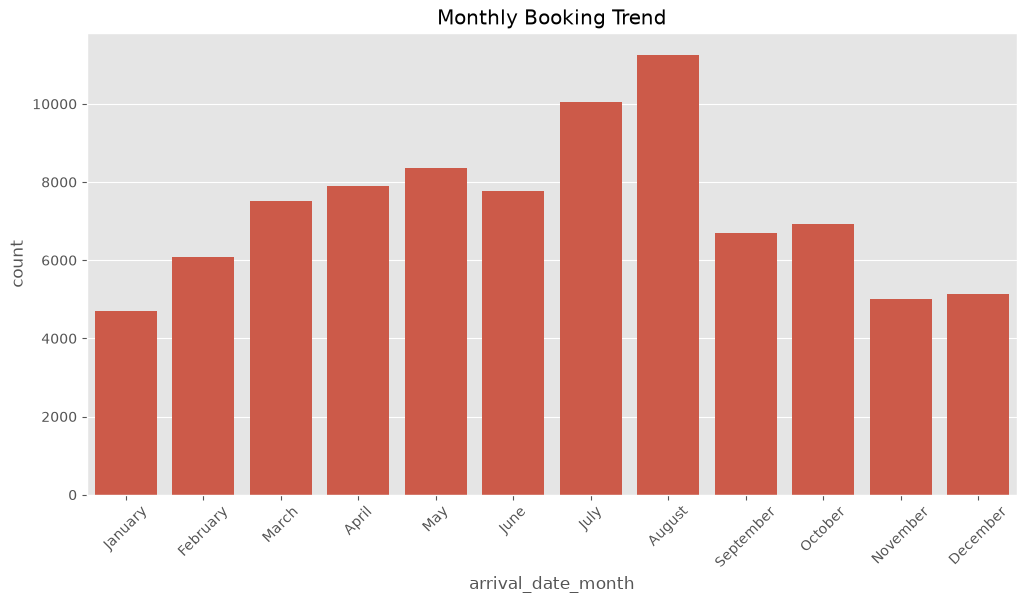

In [8]:
months = [
'January',
'February',
'March',
'April',
'May',
'June',
'July',
'August',
'September',
'October',
'November',
'December'
]

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='arrival_date_month',
    order=months
)

plt.xticks(rotation=45)

plt.title("Monthly Booking Trend")

plt.show()

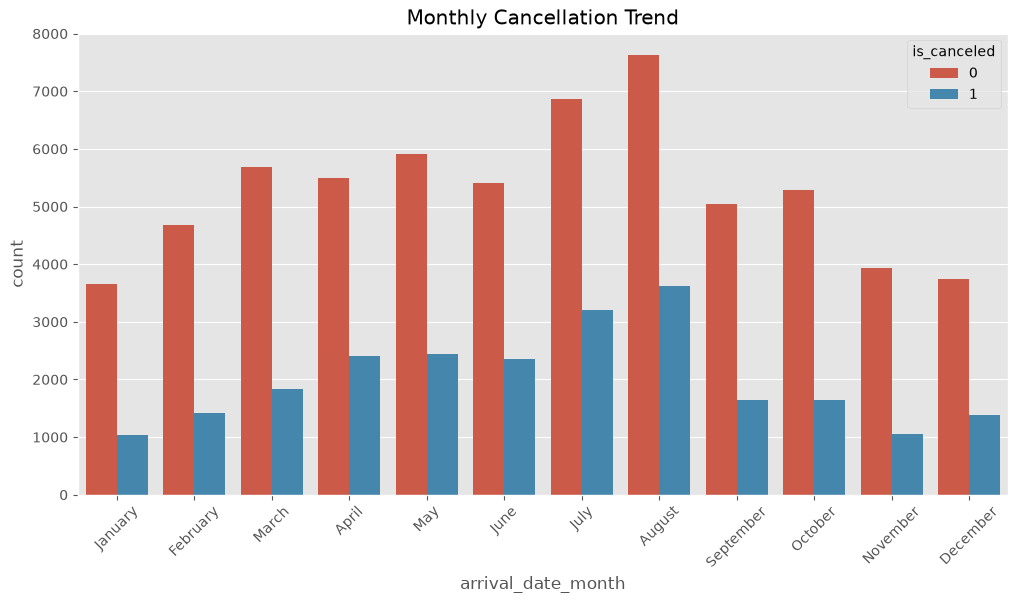

In [9]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='arrival_date_month',
    hue='is_canceled',
    order=months
)

plt.xticks(rotation=45)

plt.title("Monthly Cancellation Trend")

plt.show()

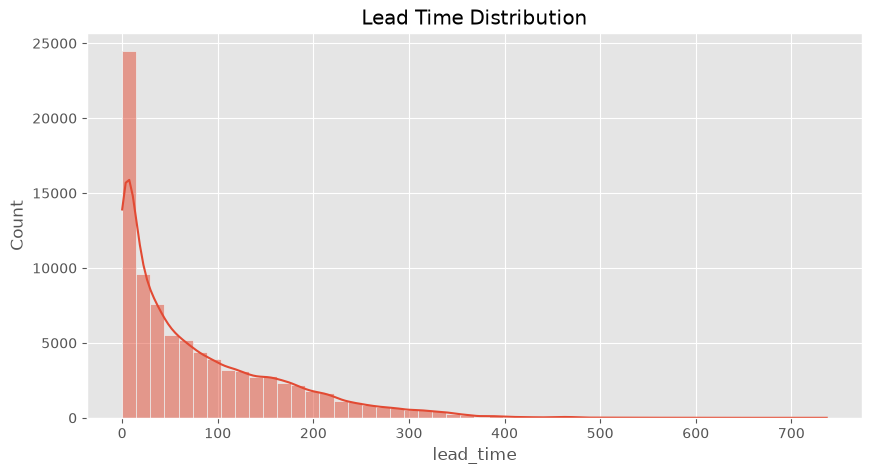

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['lead_time'],
    bins=50,
    kde=True
)

plt.title("Lead Time Distribution")

plt.show()

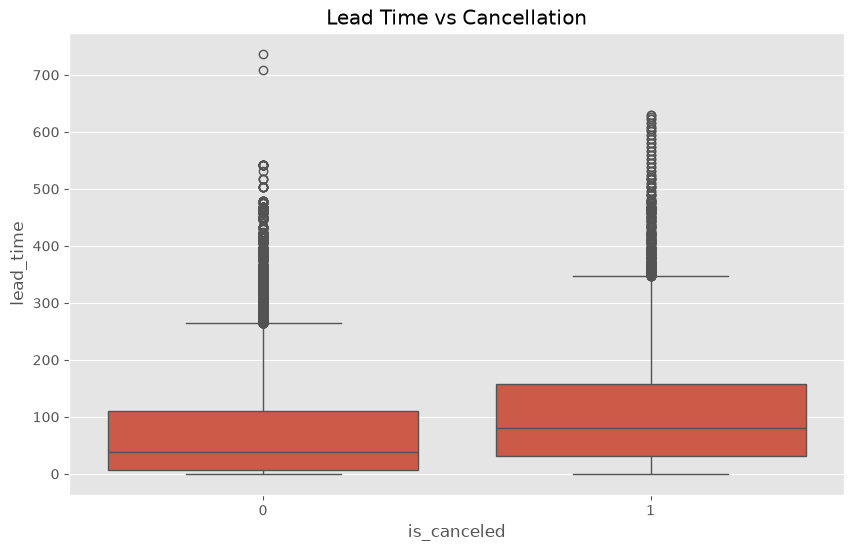

In [11]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='is_canceled',
    y='lead_time'
)

plt.title("Lead Time vs Cancellation")

plt.show()

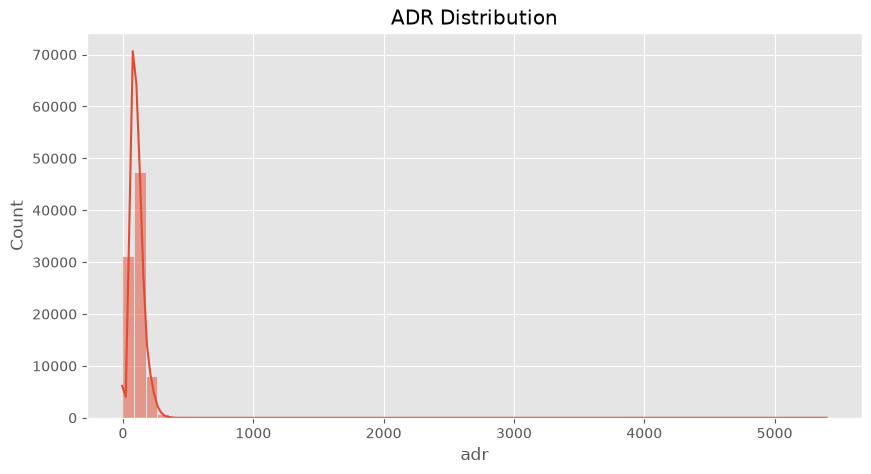

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['adr'],
    bins=60,
    kde=True
)

plt.title("ADR Distribution")

plt.show()

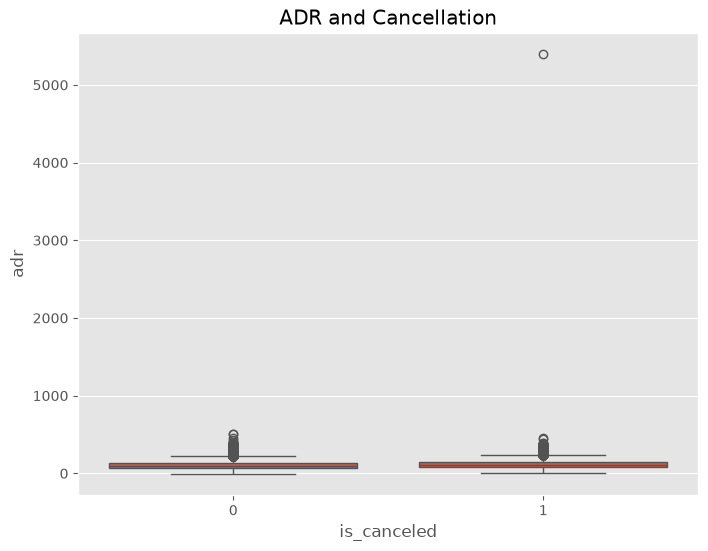

In [13]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='is_canceled',
    y='adr'
)

plt.title("ADR and Cancellation")

plt.show()

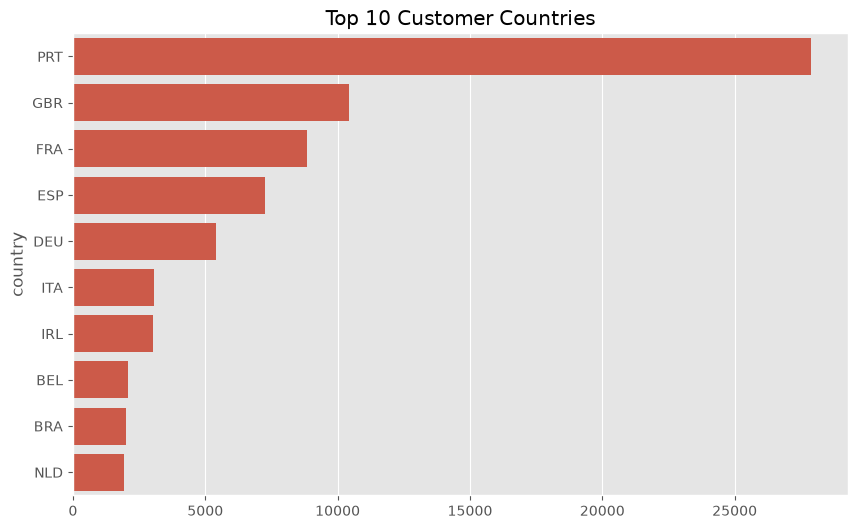

In [14]:
top_country = df['country'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_country.values,
    y=top_country.index
)

plt.title("Top 10 Customer Countries")

plt.show()

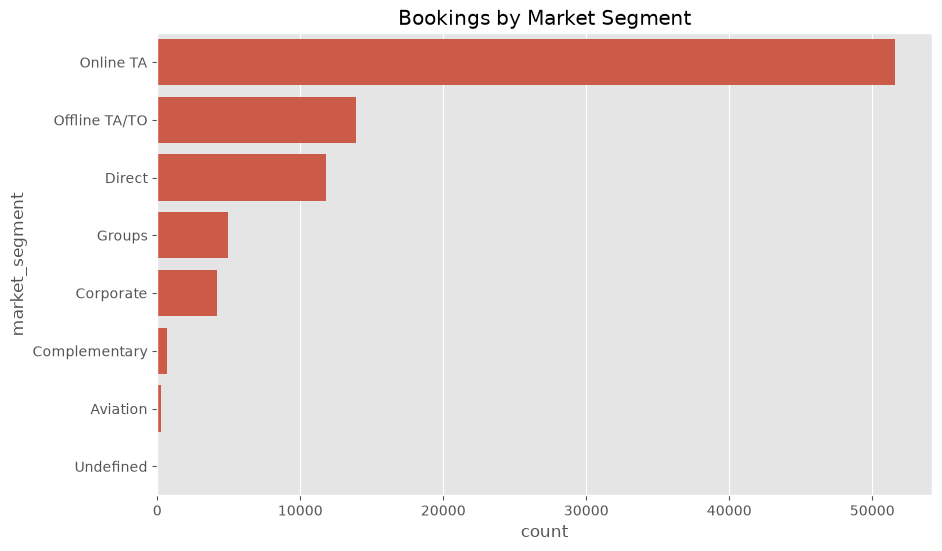

In [15]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y='market_segment',
    order=df['market_segment'].value_counts().index
)

plt.title("Bookings by Market Segment")

plt.show()

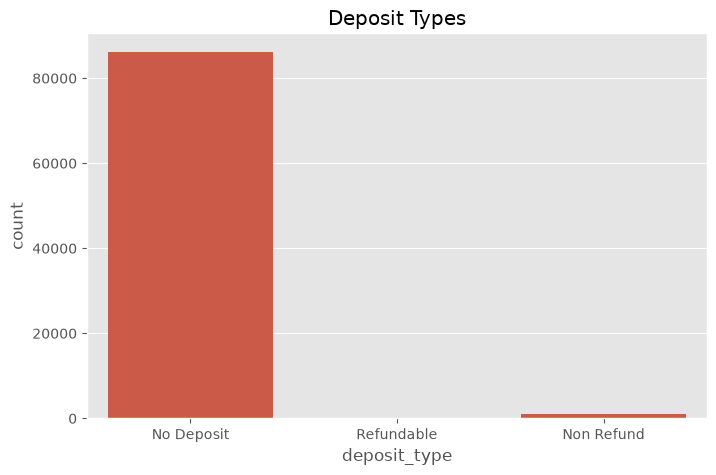

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='deposit_type'
)

plt.title("Deposit Types")

plt.show()

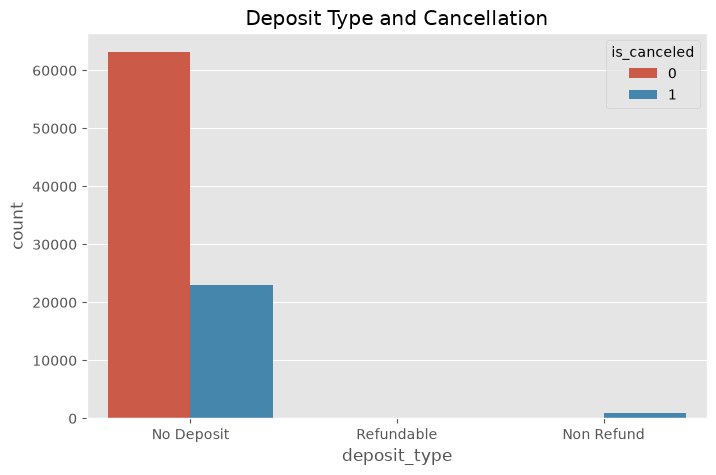

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='deposit_type',
    hue='is_canceled'
)

plt.title("Deposit Type and Cancellation")

plt.show()

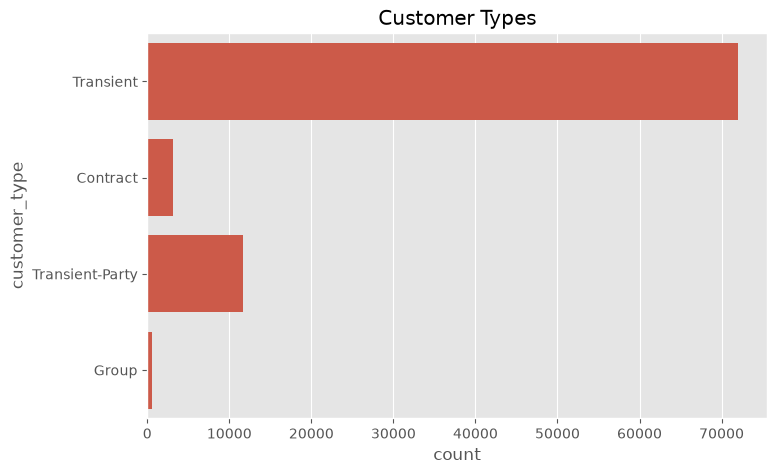

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    y='customer_type'
)

plt.title("Customer Types")

plt.show()

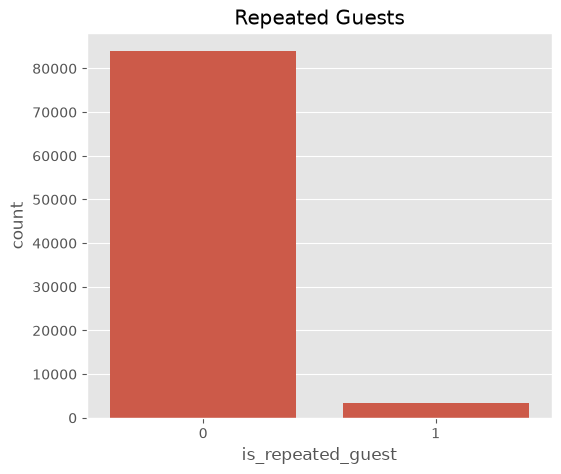

In [19]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='is_repeated_guest'
)

plt.title("Repeated Guests")

plt.show()

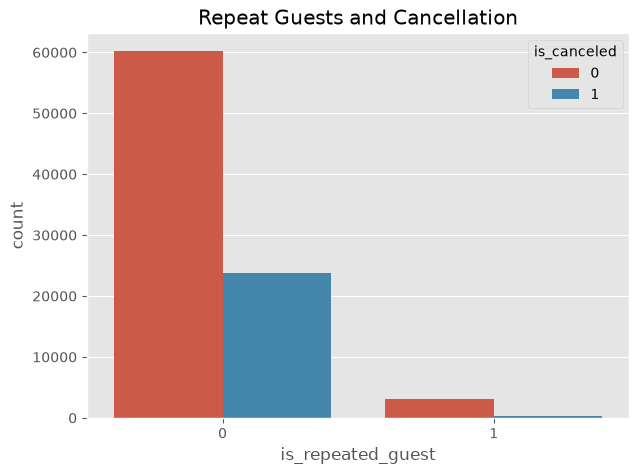

In [20]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='is_repeated_guest',
    hue='is_canceled'
)

plt.title("Repeat Guests and Cancellation")

plt.show()

In [21]:
numeric_df = df.select_dtypes(include=['number'])

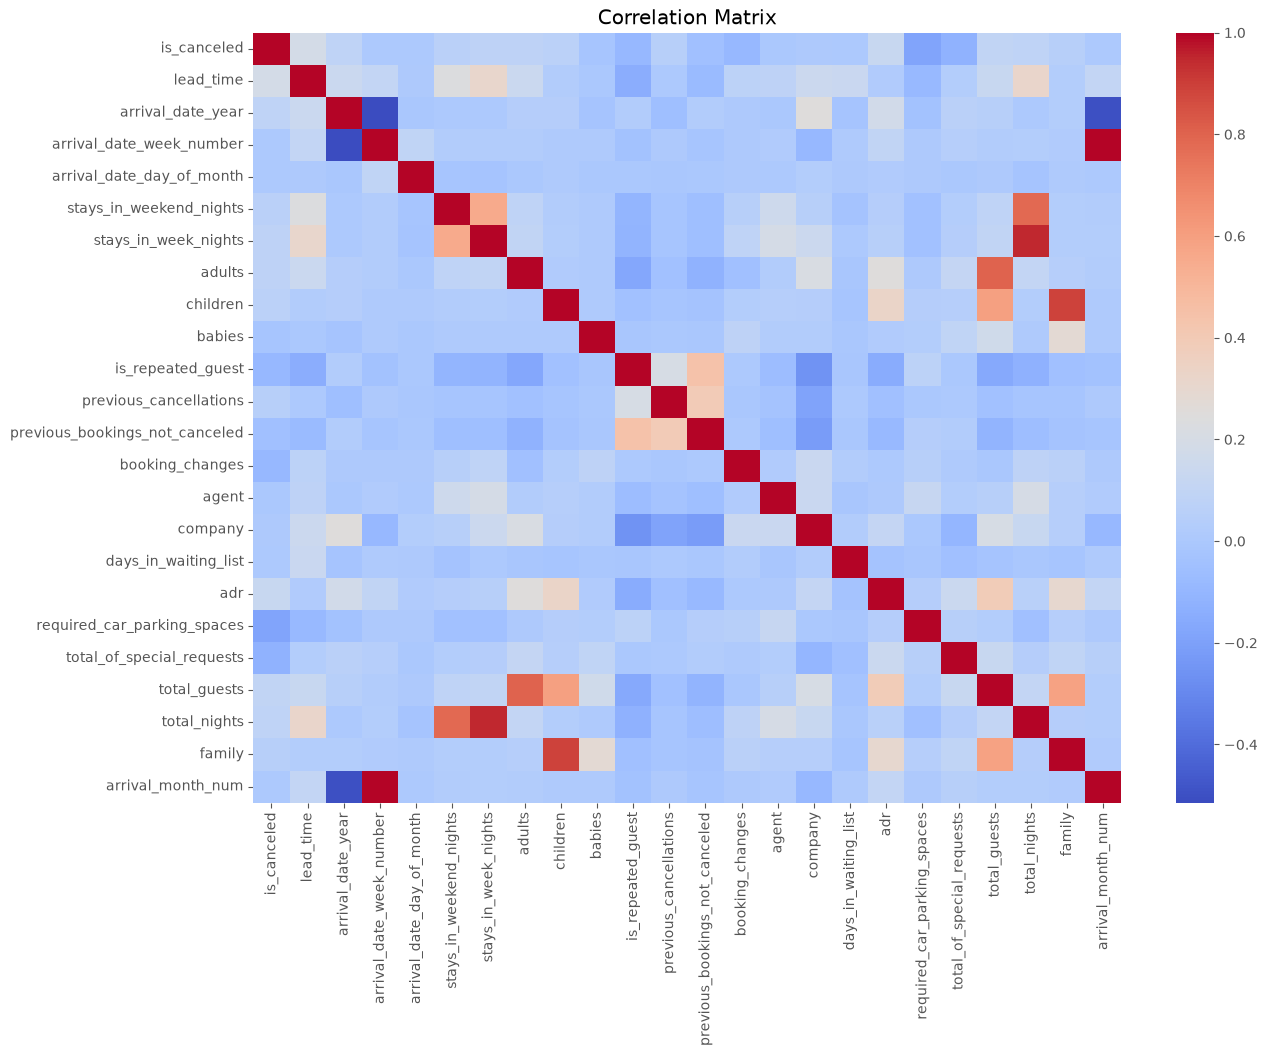

In [22]:
plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Matrix")

plt.show()

The exploratory analysis revealed several factors strongly associated with booking cancellations. Longer lead times, specific deposit policies, and certain market segments exhibited higher cancellation rates. Seasonal booking patterns were also identified, with demand peaking during the summer months. These findings will guide the feature selection process for the Machine Learning models and will form the basis of the Business Intelligence dashboard.